# Прогнозирование цены автомобиля (CarPrice_Assignment)

**Цель работы:** построить и сравнить регрессионные модели (линейная, Lasso, Ridge) для предсказания цены автомобиля `price`, оценить мультиколлинеарность признаков, снизить размерность с помощью PCA и сравнить качество моделей на исходных признаках и на главных компонентах.

Датасет: `CarPrice_Assignment.csv` (205 наблюдений, 26 столбцов). Источник: Kaggle — "Car Price Prediction Multiple Linear Regression" (https://www.kaggle.com/datasets/hellbuoy/car-price-prediction).

**План работы:**
1. Загрузка датасета
2. Первичный анализ и визуализация
3. Предобработка данных (пропуски, кодирование категорий)
4. Матрица корреляций и VIF (мультиколлинеарность)
5. Линейная / Lasso / Ridge регрессия на исходных признаках (train/test, кросс-валидация, RMSE/R²/MAPE)
6. Устранение мультиколлинеарности через PCA (со стандартизацией)
7. Те же модели на главных компонентах + сравнение метрик


## 1. Загрузка датасета

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

df = pd.read_csv("data/CarPrice_Assignment.csv")
print(df.shape)
df.head()


(205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_ID,205.0,NaN,NaN,NaN,103.0,59.322565,1.0,52.0,103.0,154.0,205.0
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
CarName,205,147,peugeot 504,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fueltype,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doornumber,205,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carbody,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivewheel,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enginelocation,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbase,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


## 2. Первичный анализ и визуализация

Столбец `CarName` содержит марку и модель. Для анализа извлечём только марку (`CompanyName`), т.к. полное название модели — это, по сути, идентификатор с почти уникальным значением на каждую строку и не несёт обобщающей информации для регрессии. `car_ID` — тоже идентификатор, удаляем его.


In [4]:
# Извлекаем марку автомобиля из CarName
df["CompanyName"] = df["CarName"].apply(lambda x: x.split(" ")[0].lower())

# Исправляем опечатки в названиях марок
brand_fix = {
    "maxda": "mazda",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen",
    "alfa-romero": "alfa-romeo"
}
df["CompanyName"] = df["CompanyName"].replace(brand_fix)

df = df.drop(columns=["car_ID", "CarName"])
print(df["CompanyName"].nunique(), "уникальных марок")
df["CompanyName"].value_counts()


22 уникальных марок


CompanyName
toyota        32
nissan        18
mazda         17
honda         13
mitsubishi    13
subaru        12
volkswagen    12
peugeot       11
volvo         11
dodge          9
bmw            8
buick          8
audi           7
plymouth       7
saab           6
porsche        5
isuzu          4
alfa-romeo     3
chevrolet      3
jaguar         3
renault        2
mercury        1
Name: count, dtype: int64

In [5]:
# Проверка пропущенных значений
missing = df.isnull().sum()
print("Пропущенные значения по столбцам:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

# Проверка дубликатов
print("\nКоличество полных дубликатов строк:", df.duplicated().sum())


Пропущенные значения по столбцам:
Пропусков нет

Количество полных дубликатов строк: 0


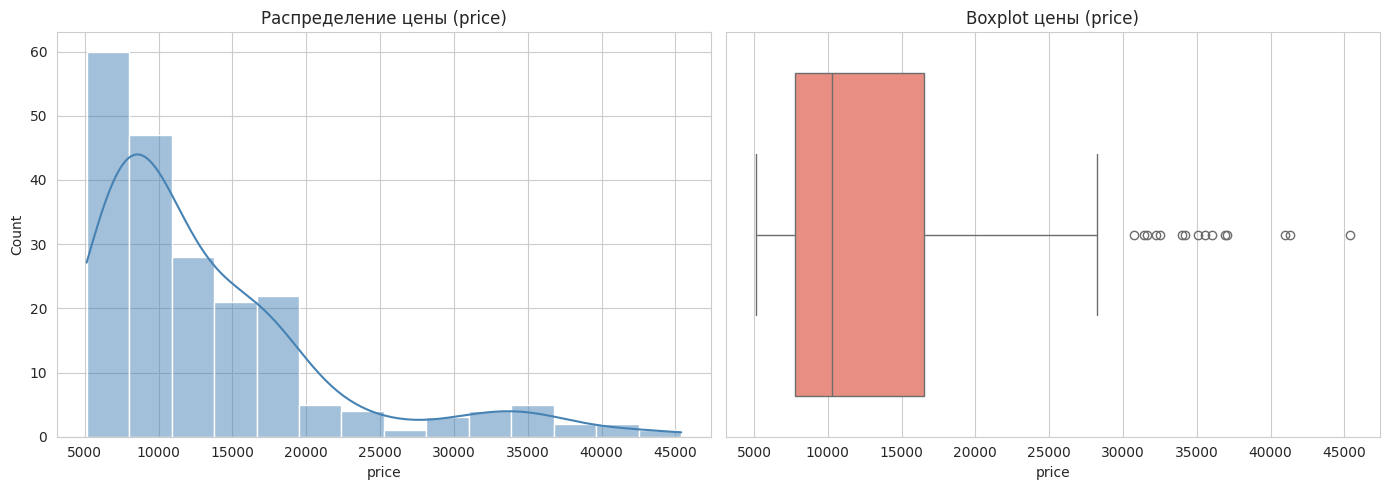

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64
Skewness: 1.78


In [6]:
# Распределение целевой переменной price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение цены (price)")
sns.boxplot(x=df["price"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot цены (price)")
plt.tight_layout()
plt.show()

print(df["price"].describe())
print("Skewness:", df["price"].skew().round(2))


Целевая переменная имеет правостороннюю асимметрию (skewness > 1): большинство автомобилей недорогие, но есть выборка дорогих моделей.

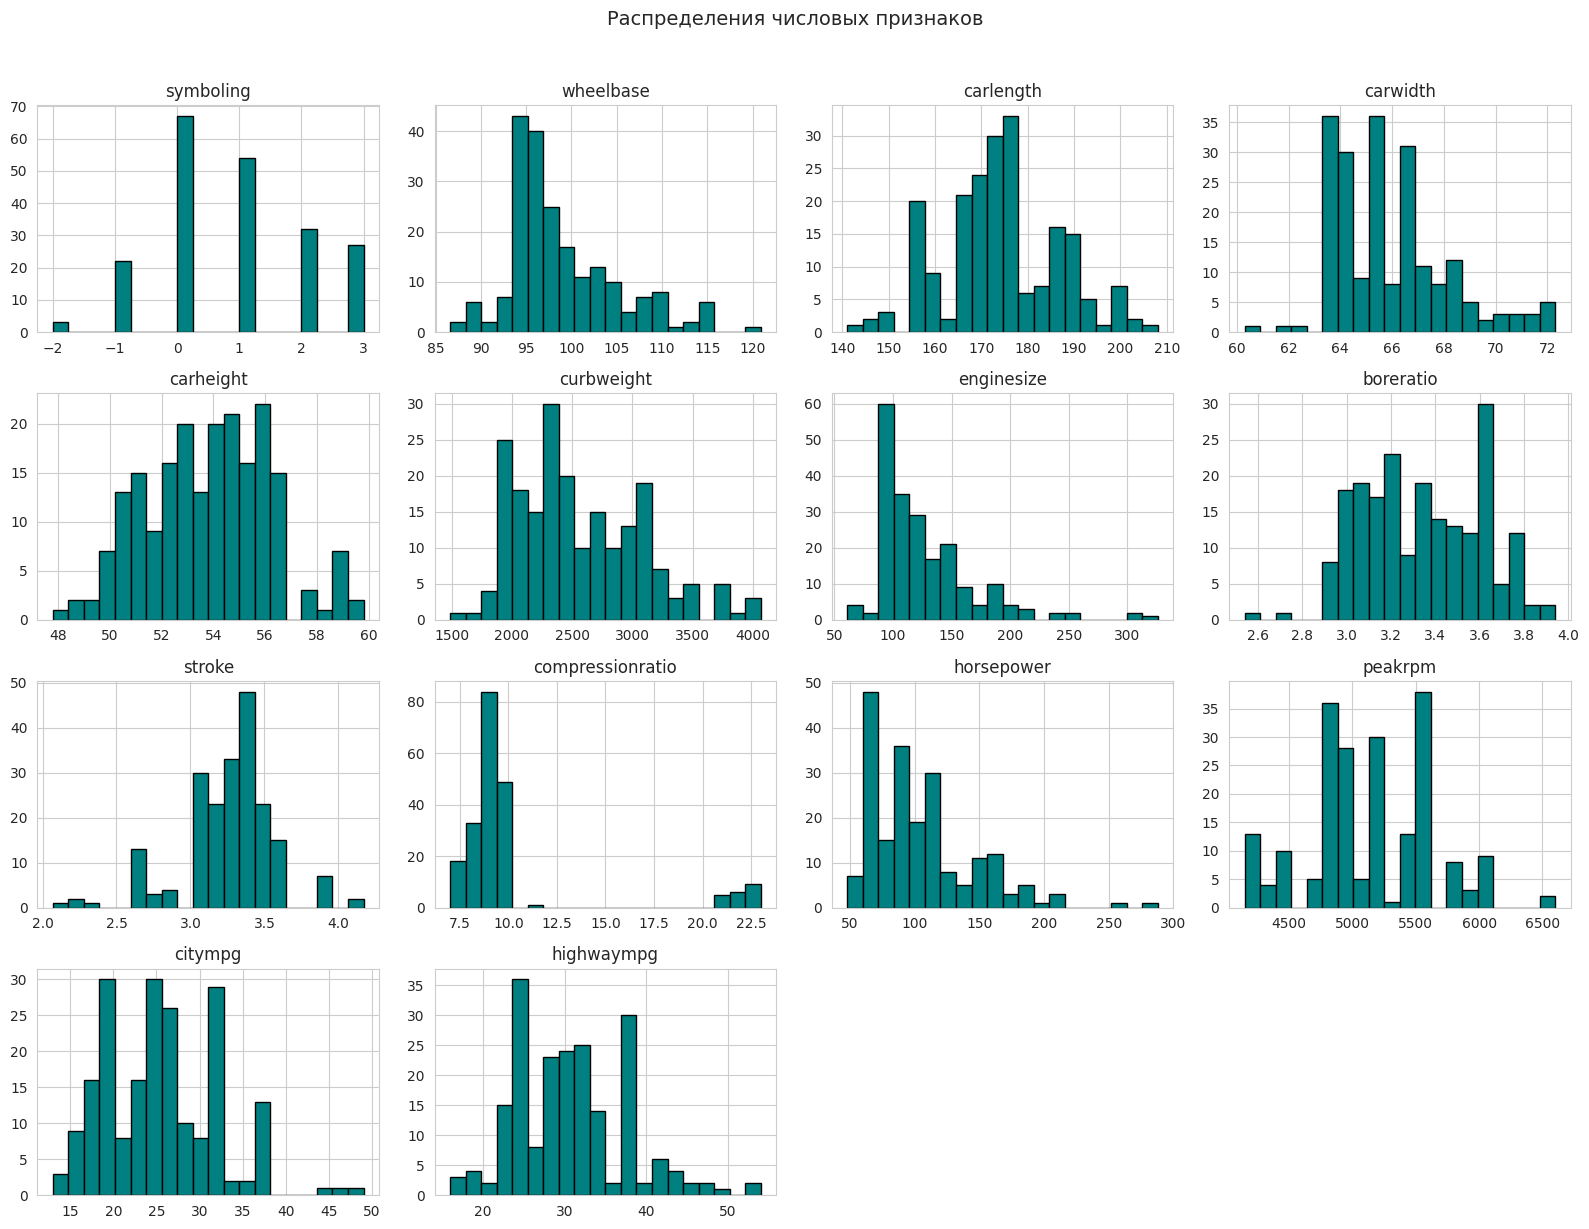

In [7]:
# Распределения числовых признаков
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("price")

df[num_cols].hist(bins=20, figsize=(16, 12), color="teal", edgecolor="black")
plt.suptitle("Распределения числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_139/1300201100.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


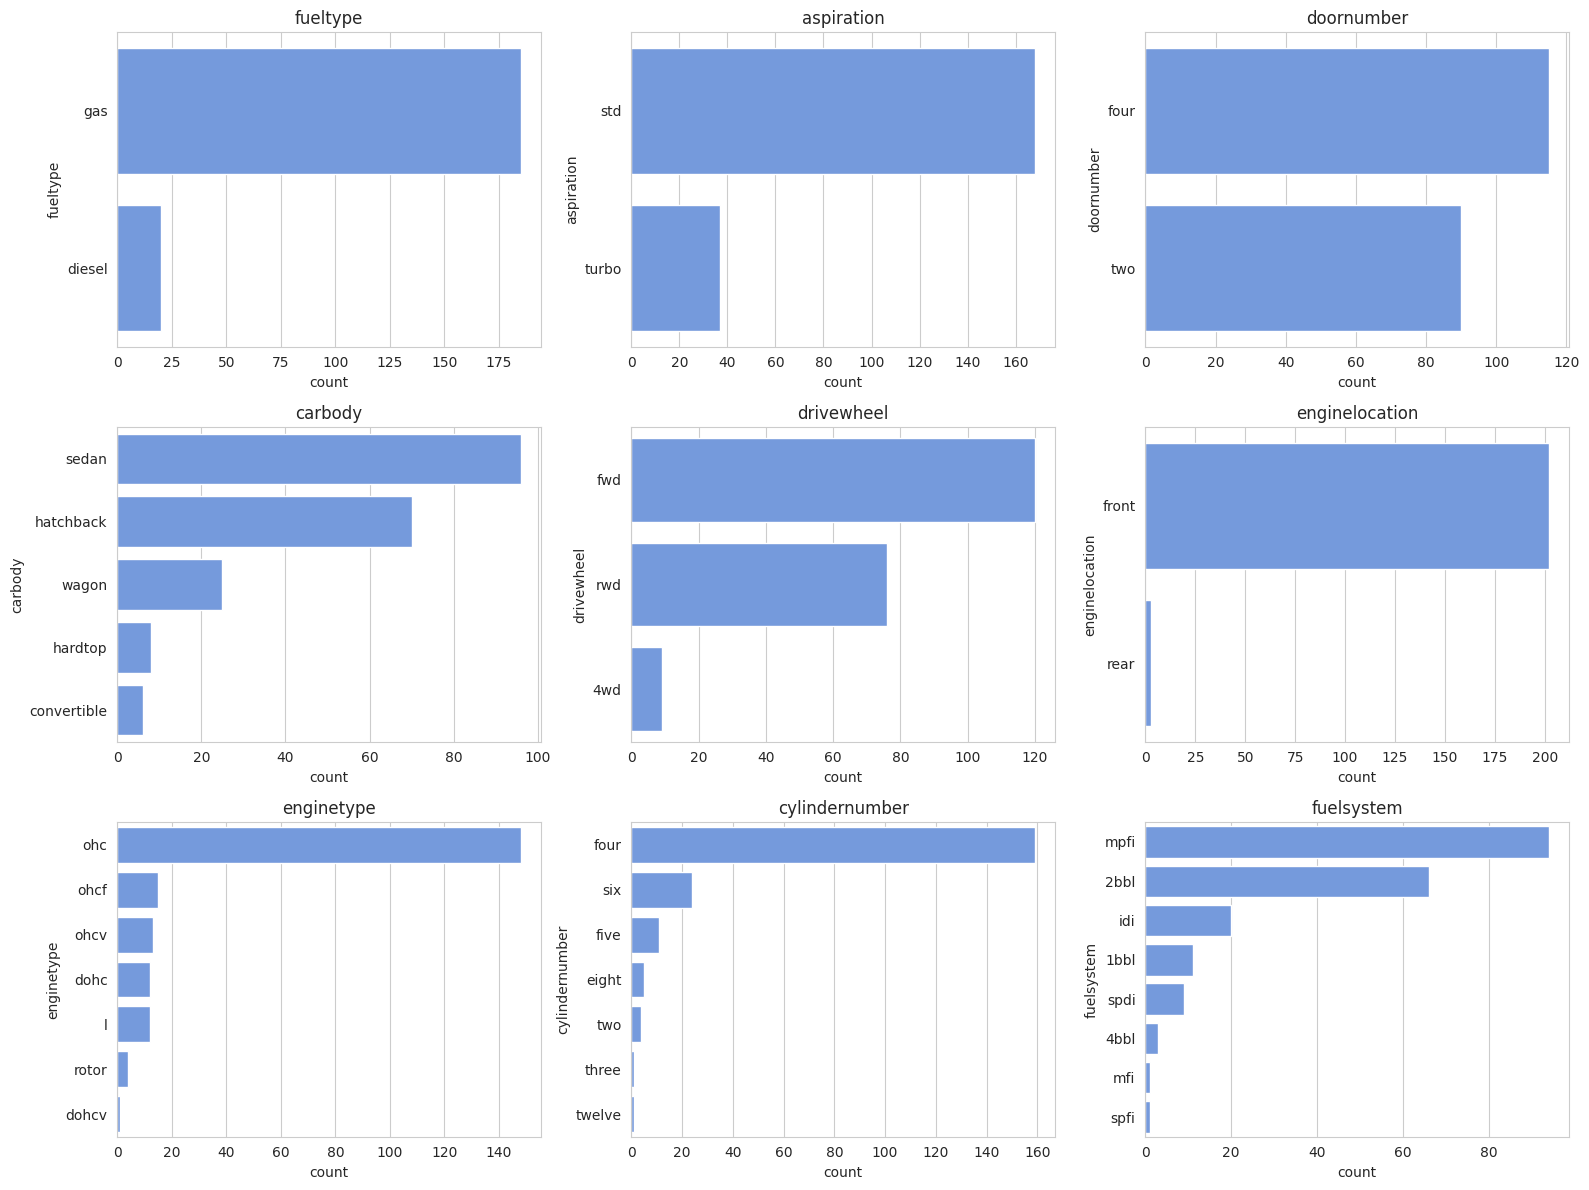

In [8]:
# Распределения категориальных признаков
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("CompanyName")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index, color="cornflowerblue")
    axes[i].set_title(col)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


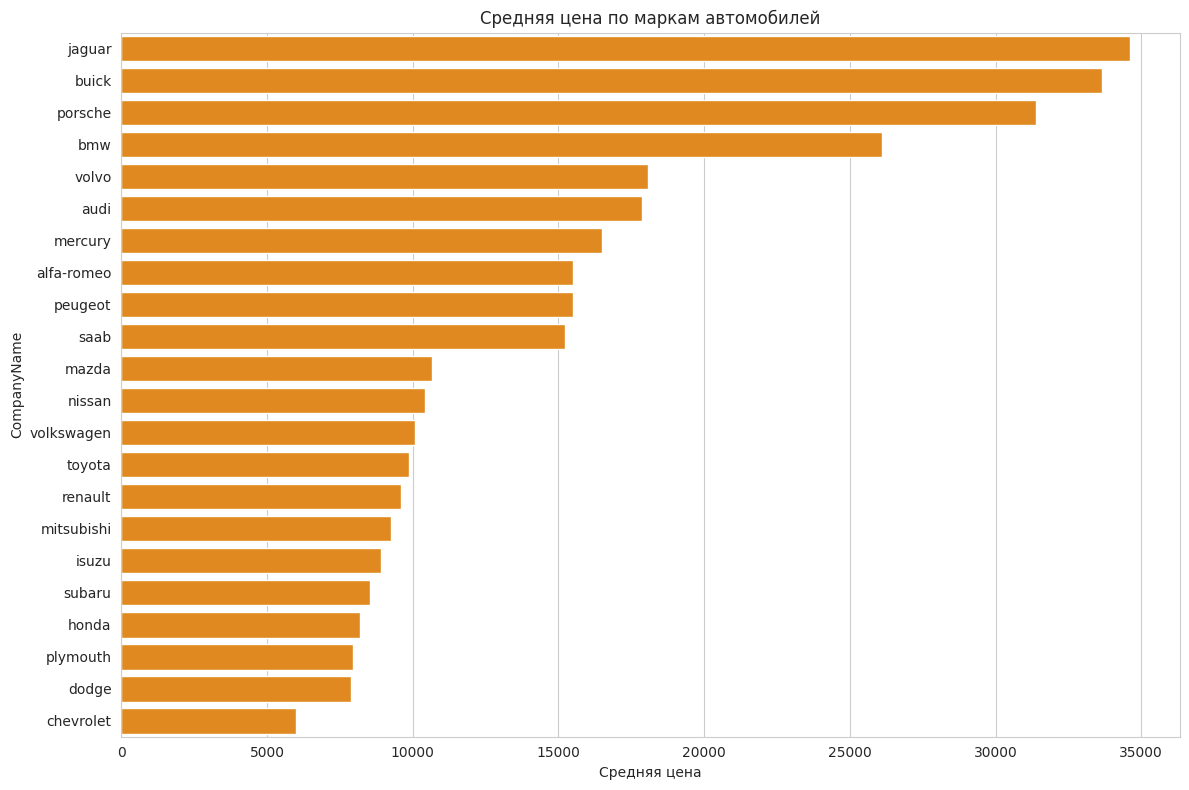

In [9]:
# Средняя цена по маркам
plt.figure(figsize=(12, 8))
brand_price = df.groupby("CompanyName")["price"].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.values, y=brand_price.index, color="darkorange")
plt.title("Средняя цена по маркам автомобилей")
plt.xlabel("Средняя цена")
plt.tight_layout()
plt.show()


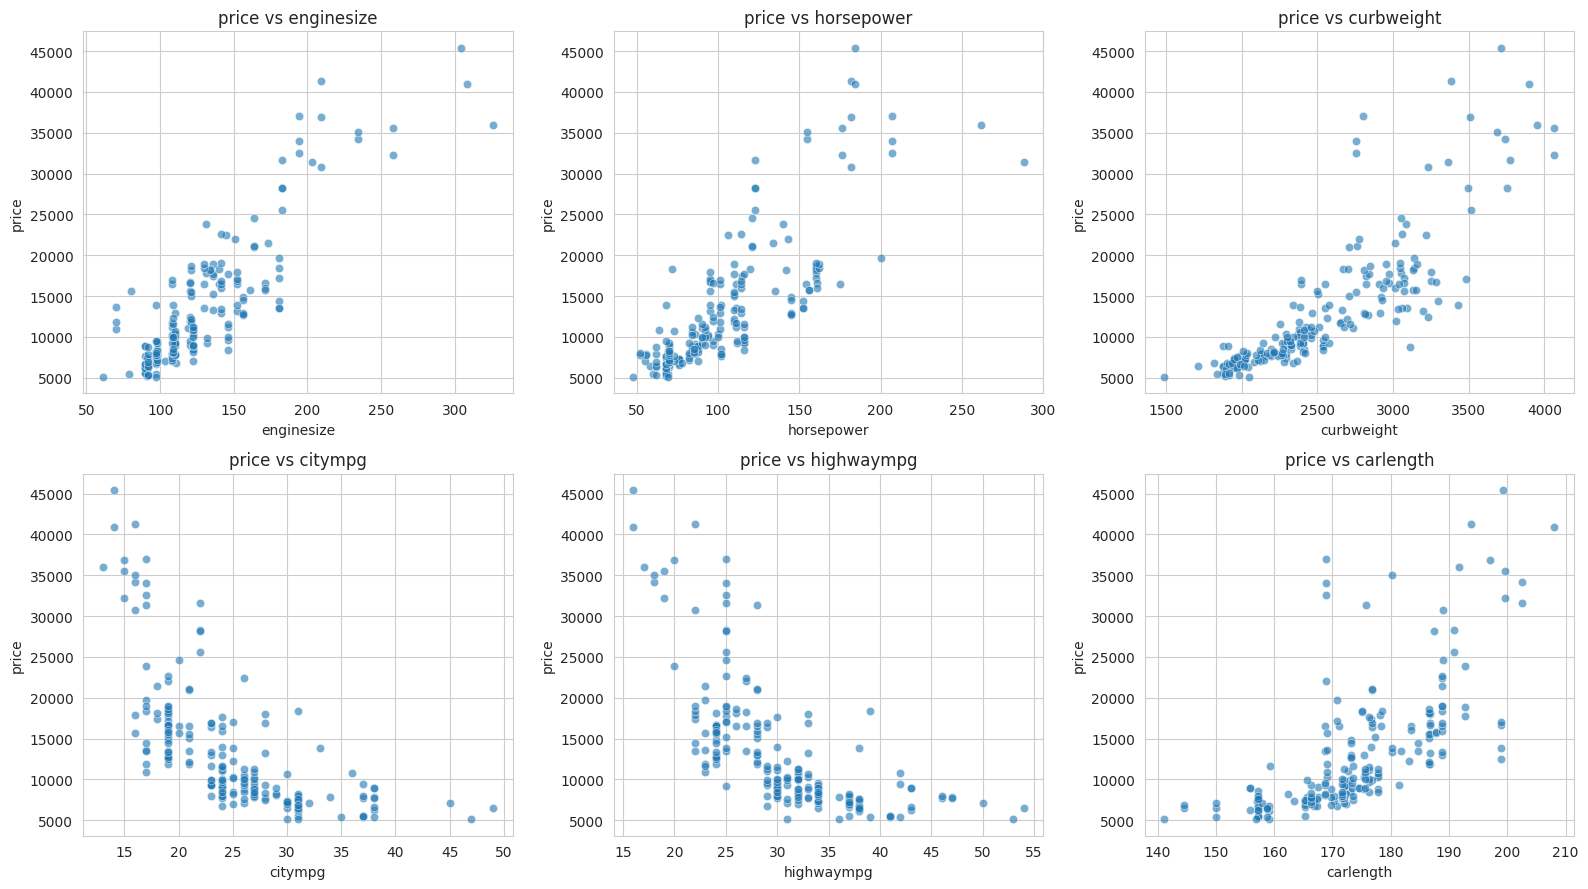

In [10]:
# Зависимость цены от ключевых числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), ["enginesize", "horsepower", "curbweight", "citympg", "highwaympg", "carlength"]):
    sns.scatterplot(x=df[col], y=df["price"], ax=ax, alpha=0.6)
    ax.set_title(f"price vs {col}")
plt.tight_layout()
plt.show()


**Выводы по разведочному анализу:**
- Пропущенных значений и дубликатов в датасете нет.
- Целевая переменная `price` смещена вправо (есть дорогие авто-выбросы).
- Цена сильно положительно связана с `enginesize`, `horsepower`, `curbweight` и отрицательно — с `citympg`/`highwaympg` (что ожидаемо: мощные тяжёлые машины дороже и менее экономичны).
- Марка автомобиля (`CompanyName`) сильно влияет на среднюю цену (премиум-бренды дороже).

## 3. Предобработка данных

- Пропущенных значений в датасете нет (проверено выше), поэтому этап удаления пропусков формально пройден без изменений.
- Категориальные признаки кодируем: бинарные (`fueltype`, `aspiration`, `doornumber`, `enginelocation`) — через label encoding (0/1), номинальные с несколькими категориями (`carbody`, `drivewheel`, `enginetype`, `cylindernumber`, `fuelsystem`, `CompanyName`) — через one-hot encoding (`pd.get_dummies`, drop_first=True, чтобы избежать дублирующей мультиколлинеарности от dummy-ловушки).


In [11]:
df_model = df.copy()

# Бинарные категориальные признаки -> 0/1
binary_map = {
    "fueltype": {"gas": 0, "diesel": 1},
    "aspiration": {"std": 0, "turbo": 1},
    "doornumber": {"two": 0, "four": 1},
    "enginelocation": {"front": 0, "rear": 1}
}
for col, mapping in binary_map.items():
    df_model[col] = df_model[col].map(mapping)

# cylindernumber записан словами - переведём в числа
word_to_num = {"two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "eight": 8, "twelve": 12}
df_model["cylindernumber"] = df_model["cylindernumber"].map(word_to_num)

# Номинальные категориальные признаки -> one-hot encoding
nominal_cols = ["carbody", "drivewheel", "enginetype", "fuelsystem", "CompanyName"]
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

# приводим bool-столбцы (появившиеся после get_dummies) к int
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print("Итоговая размерность после кодирования:", df_model.shape)
df_model.head()


Итоговая размерность после кодирования: (205, 60)


,symboling,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,CompanyName_nissan,CompanyName_peugeot,CompanyName_plymouth,CompanyName_porsche,CompanyName_renault,CompanyName_saab,CompanyName_subaru,CompanyName_toyota,CompanyName_volkswagen,CompanyName_volvo
0,3,0,0,0,0,88.6,168.8,64.1,48.8,2548,...,0,0,0,0,0,0,0,0,0,0
1,3,0,0,0,0,88.6,168.8,64.1,48.8,2548,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,94.5,171.2,65.5,52.4,2823,...,0,0,0,0,0,0,0,0,0,0
3,2,0,0,1,0,99.8,176.6,66.2,54.3,2337,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,1,0,99.4,176.6,66.4,54.3,2824,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Финальная проверка пропусков после предобработки
print("Пропуски после кодирования:", df_model.isnull().sum().sum())


Пропуски после кодирования: 0


## 4. Матрица корреляций и анализ мультиколлинеарности (VIF)

Для наглядности матрицу корреляций строим по исходным числовым признакам (до one-hot кодирования), а VIF считаем на полном закодированном наборе признаков, который пойдёт в модель.


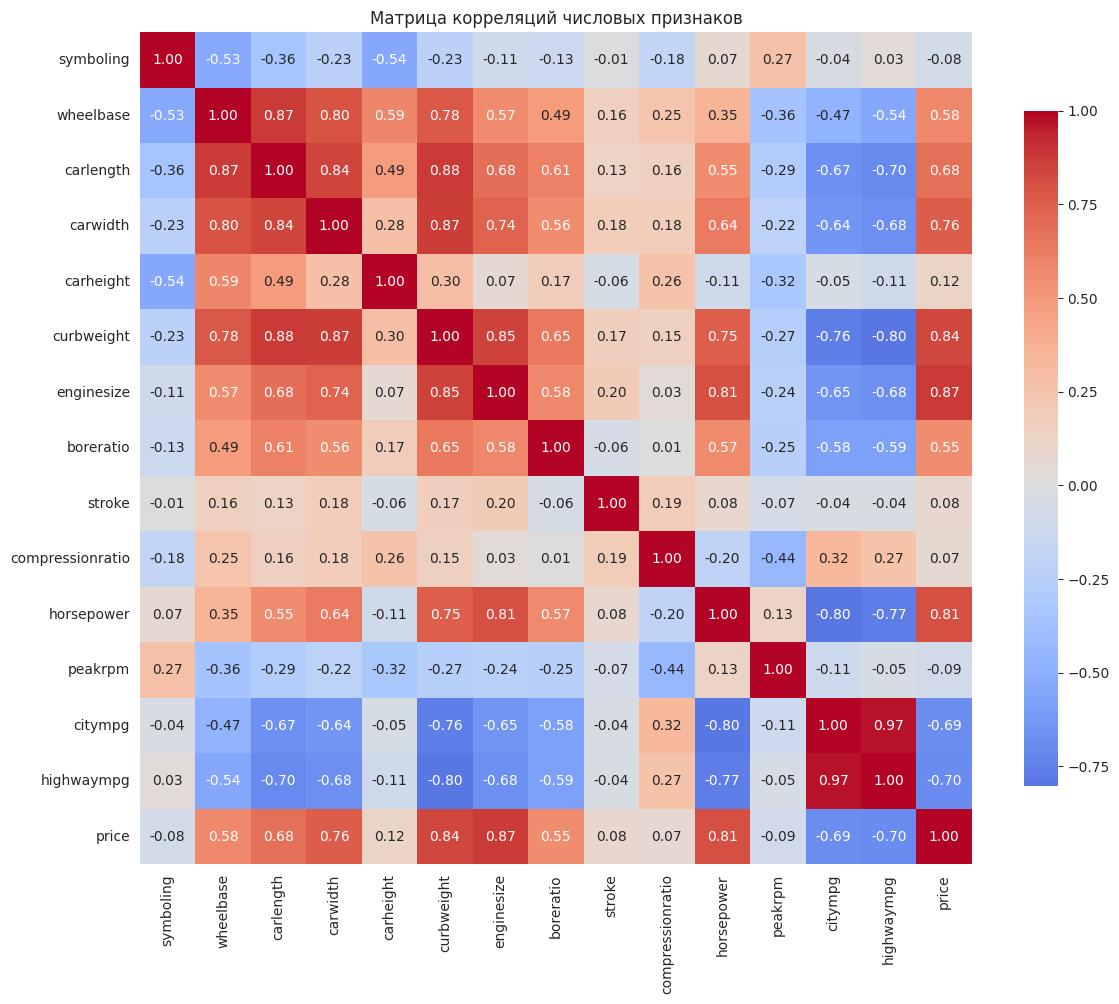

In [13]:
plt.figure(figsize=(12, 10))
corr = df[num_cols + ["price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Матрица корреляций числовых признаков")
plt.tight_layout()
plt.show()


In [14]:
# Наиболее коррелирующие с ценой признаки
price_corr = corr["price"].drop("price").sort_values(key=abs, ascending=False)
print("Корреляция признаков с ценой (по убыванию модуля):")
print(price_corr)


Корреляция признаков с ценой (по убыванию модуля):
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
highwaympg         -0.697599
citympg            -0.685751
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
peakrpm            -0.085267
symboling          -0.079978
stroke              0.079443
compressionratio    0.067984
Name: price, dtype: float64


Матрица показывает, что многие признаки, описывающие "размер/мощность автомобиля" (`enginesize`, `curbweight`, `horsepower`, `carwidth`, `carlength`, `wheelbase`), сильно коррелируют не только с ценой, но и **друг с другом** (коэффициенты 0.7–0.9) — это явный признак мультиколлинеарности. Аналогично `citympg` и `highwaympg` коррелируют почти идеально (~0.97). Проверим это формально через VIF.

In [15]:
X_all = df_model.drop(columns=["price"])
y_all = df_model["price"]

# VIF считаем на стандартизированных признаках (без учёта константы, statsmodels требует добавить intercept)
X_vif = X_all.copy().astype(float)
X_vif_scaled = pd.DataFrame(StandardScaler().fit_transform(X_vif), columns=X_vif.columns)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_data


/tmp/ipykernel_139/3201582805.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.74e+16). VIF calculations may be numerically unstable.
  vif_data["VIF"] = [variance_inflation_factor(X_vif_scaled.values, i) for i in range(X_vif_scaled.shape[1])]
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/py

,feature,VIF
0,fueltype,1.000800e+15
1,enginelocation,1.000800e+15
2,enginetype_ohcf,1.000800e+15
3,fuelsystem_idi,1.000800e+15
4,CompanyName_subaru,1.000800e+15
5,compressionratio,1.767388e+02
6,enginesize,6.357978e+01
7,citympg,4.954043e+01
8,horsepower,4.459772e+01
9,highwaympg,4.118672e+01


In [16]:
high_vif = vif_data[vif_data["VIF"] > 10]
print(f"Признаков с VIF > 10 (сильная мультиколлинеарность): {len(high_vif)} из {len(vif_data)}")
high_vif


Признаков с VIF > 10 (сильная мультиколлинеарность): 35 из 59


,feature,VIF
0,fueltype,1.000800e+15
1,enginelocation,1.000800e+15
2,enginetype_ohcf,1.000800e+15
3,fuelsystem_idi,1.000800e+15
4,CompanyName_subaru,1.000800e+15
5,compressionratio,1.767388e+02
6,enginesize,6.357978e+01
7,citympg,4.954043e+01
8,horsepower,4.459772e+01
9,highwaympg,4.118672e+01


**Вывод по мультиколлинеарности:** значительная часть признаков (обычно принято считать VIF > 10 как порог сильной мультиколлинеарности, VIF > 5 — умеренной) имеет очень высокий VIF. Это ожидаемо для геометрических/технических характеристик автомобиля (длина, ширина, колёсная база, объём двигателя, вес и т.д. — все они измеряют по сути "размер и мощность машины" и линейно взаимозависимы), а также для one-hot закодированных марок автомобилей, которые коррелируют между собой по построению (dummy-переменные внутри одной группы). 

Мультиколлинеарность не мешает **прогнозной силе** линейной регрессии, но делает коэффициенты модели нестабильными и трудноинтерпретируемыми, а также объясняет, почему методы регуляризации (Lasso/Ridge) и снижение размерности (PCA) полезны в этой задаче — это будет продемонстрировано в следующих шагах.

## 5. Регрессионные модели на исходных признаках

Целевая переменная `price` — непрерывная, поэтому строим модели линейной, Lasso и Ridge регрессии (логистическая регрессия не применяется, т.к. задача не является классификацией).

Разбиваем выборку 80/20, признаки стандартизируем (важно для Lasso/Ridge, т.к. регуляризация чувствительна к масштабу). Гиперпараметр регуляризации подбираем кросс-валидацией (5 фолдов) с помощью `LassoCV`/`RidgeCV`.


In [17]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (164, 59)  Test: (41, 59)


In [18]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """Обучает модель, считает метрики на тесте и кросс-валидацию (RMSE) на трейне."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=kf, scoring="neg_mean_squared_error"))
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="r2")

    return {
        "RMSE (test)": rmse,
        "R2 (test)": r2,
        "MAPE % (test)": mape,
        "CV RMSE (mean)": cv_rmse.mean(),
        "CV R2 (mean)": cv_r2.mean()
    }, y_pred


In [19]:
# Подбор alpha для Lasso и Ridge кросс-валидацией
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=20000).fit(X_train_scaled, y_train)
ridge_cv = RidgeCV(cv=5, alphas=np.logspace(-3, 3, 100)).fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.alpha_
best_alpha_ridge = ridge_cv.alpha_
print(f"Оптимальный alpha для Lasso: {best_alpha_lasso:.4f}")
print(f"Оптимальный alpha для Ridge: {best_alpha_ridge:.4f}")


Оптимальный alpha для Lasso: 41.0558
Оптимальный alpha для Ridge: 15.1991


In [20]:
results_orig = {}
predictions_orig = {}

models_orig = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=best_alpha_lasso, max_iter=20000),
    "Ridge": Ridge(alpha=best_alpha_ridge)
}

for name, model in models_orig.items():
    metrics, y_pred = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results_orig[name] = metrics
    predictions_orig[name] = y_pred

results_orig_df = pd.DataFrame(results_orig).T
results_orig_df


,RMSE (test),R2 (test),MAPE % (test),CV RMSE (mean),CV R2 (mean)
Linear Regression,2878.118434,0.895070,15.573442,2750.109293,0.864014
Lasso,3057.019175,0.881620,17.021705,2414.189271,0.895794
Ridge,3134.216241,0.875566,16.562778,2290.548320,0.903417


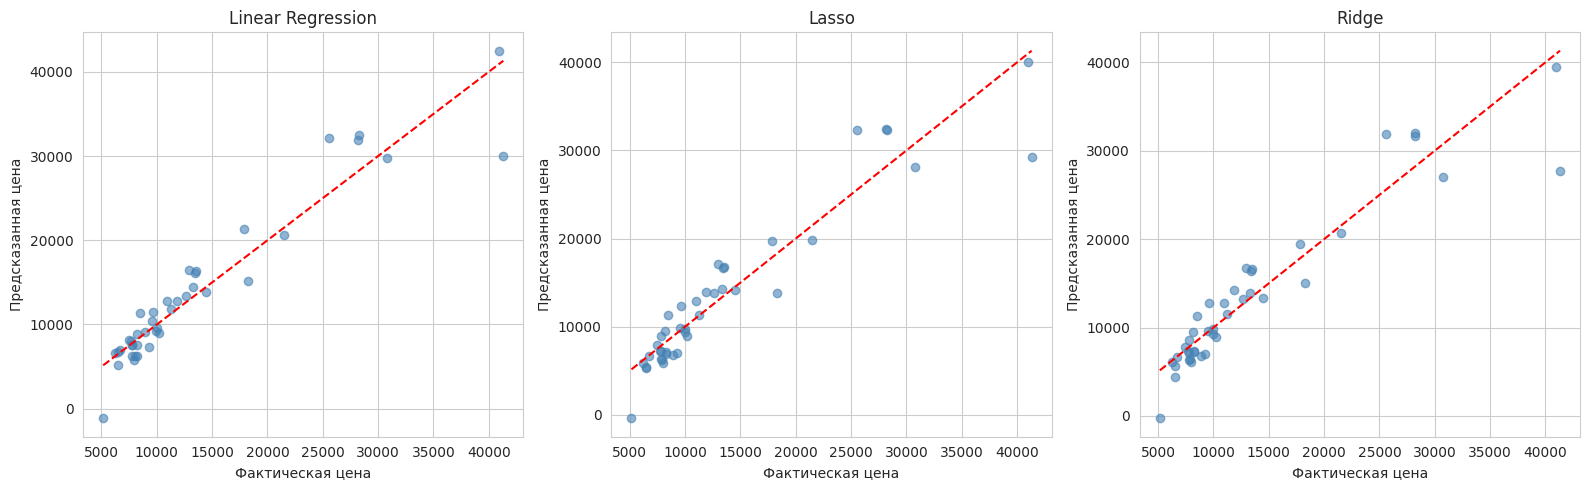

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, y_pred) in zip(axes, predictions_orig.items()):
    ax.scatter(y_test, y_pred, alpha=0.6, color="steelblue")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_xlabel("Фактическая цена")
    ax.set_ylabel("Предсказанная цена")
    ax.set_title(name)
plt.tight_layout()
plt.show()


**Промежуточный вывод:** все три модели показывают близкое качество на исходных признаках, т.к. Lasso и Ridge подобрали небольшую степень регуляризации — данных относительно немного (205 строк), а число признаков после one-hot кодирования велико, поэтому регуляризация помогает не переобучиться, но принципиально не меняет качество по сравнению с обычной линейной регрессией. Далее посмотрим, что даёт снижение размерности через PCA.

## 6. Снижение размерности: PCA

Перед PCA обязательно стандартизируем признаки (среднее 0, дисперсия 1), т.к. PCA чувствителен к масштабу переменных. Компоненты выбираем так, чтобы объяснить не менее 90% дисперсии.


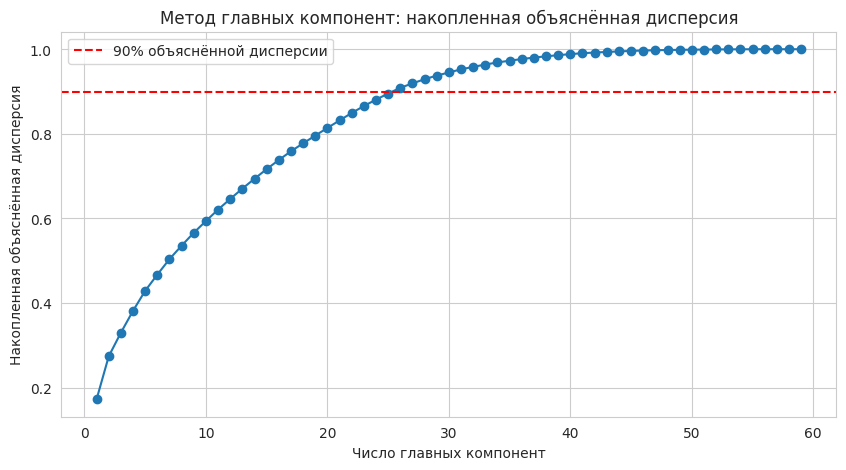

Число компонент, объясняющих >=90% дисперсии: 26 (из 59 исходных признаков)


In [22]:
# Стандартизация всего набора признаков (используем те же scaler-параметры, обученные на трейне)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% объяснённой дисперсии")
plt.xlabel("Число главных компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("Метод главных компонент: накопленная объяснённая дисперсия")
plt.legend()
plt.grid(True)
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Число компонент, объясняющих >=90% дисперсии: {n_components_90} (из {X_train_scaled.shape[1]} исходных признаков)")


In [23]:
pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Размерность после PCA (train):", X_train_pca.shape)
print("Суммарная объяснённая дисперсия:", pca.explained_variance_ratio_.sum().round(4))


Размерность после PCA (train): (164, 26)
Суммарная объяснённая дисперсия: 0.9088


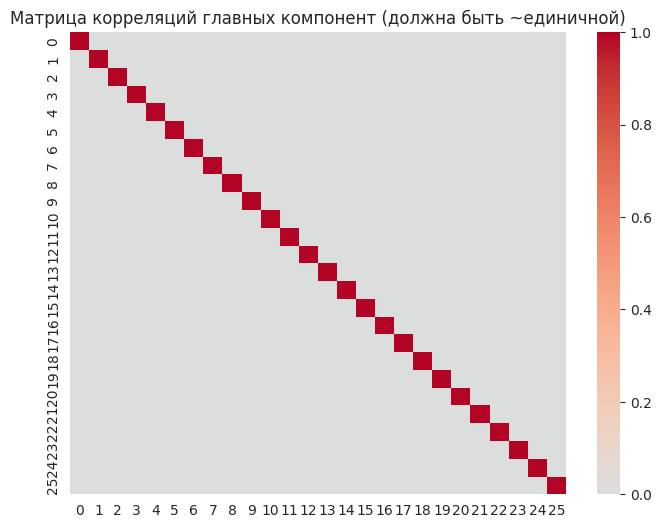

Максимальная корреляция между разными компонентами: 0.0


In [24]:
# Проверяем, что главные компоненты не коррелируют друг с другом (мультиколлинеарность устранена)
pca_corr = np.corrcoef(X_train_pca.T)
plt.figure(figsize=(8, 6))
sns.heatmap(pca_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Матрица корреляций главных компонент (должна быть ~единичной)")
plt.show()

print("Максимальная корреляция между разными компонентами:",
      np.abs(pca_corr - np.eye(pca_corr.shape[0])).max().round(6))


Матрица корреляций компонент близка к единичной — это подтверждает, что PCA полностью устранил мультиколлинеарность: главные компоненты по построению ортогональны (некоррелированы) друг с другом.

## 7. Регрессионные модели на главных компонентах

Повторяем построение линейной, Lasso и Ridge регрессии, но уже на признаках-компонентах PCA, и сравниваем метрики с моделями на исходных данных.


In [25]:
lasso_cv_pca = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=20000).fit(X_train_pca, y_train)
ridge_cv_pca = RidgeCV(cv=5, alphas=np.logspace(-3, 3, 100)).fit(X_train_pca, y_train)

best_alpha_lasso_pca = lasso_cv_pca.alpha_
best_alpha_ridge_pca = ridge_cv_pca.alpha_
print(f"Оптимальный alpha для Lasso (PCA): {best_alpha_lasso_pca:.4f}")
print(f"Оптимальный alpha для Ridge (PCA): {best_alpha_ridge_pca:.4f}")


Оптимальный alpha для Lasso (PCA): 138.5092
Оптимальный alpha для Ridge (PCA): 40.3702


In [26]:
results_pca = {}
predictions_pca = {}

models_pca = {
    "Linear Regression (PCA)": LinearRegression(),
    "Lasso (PCA)": Lasso(alpha=best_alpha_lasso_pca, max_iter=20000),
    "Ridge (PCA)": Ridge(alpha=best_alpha_ridge_pca)
}

for name, model in models_pca.items():
    metrics, y_pred = evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test)
    results_pca[name] = metrics
    predictions_pca[name] = y_pred

results_pca_df = pd.DataFrame(results_pca).T
results_pca_df


,RMSE (test),R2 (test),MAPE % (test),CV RMSE (mean),CV R2 (mean)
Linear Regression (PCA),3422.788712,0.851598,22.765132,5064.927155,0.259609
Lasso (PCA),3515.004902,0.843493,21.906100,2640.889216,0.869001
Ridge (PCA),3470.733071,0.847411,21.477378,2554.504441,0.878236


In [27]:
# Сводная таблица сравнения: исходные признаки vs главные компоненты
comparison = pd.concat([results_orig_df, results_pca_df])
comparison = comparison[["RMSE (test)", "R2 (test)", "MAPE % (test)", "CV RMSE (mean)", "CV R2 (mean)"]]
comparison.round(3)


,RMSE (test),R2 (test),MAPE % (test),CV RMSE (mean),CV R2 (mean)
Linear Regression,2878.118,0.895,15.573,2750.109,0.864
Lasso,3057.019,0.882,17.022,2414.189,0.896
Ridge,3134.216,0.876,16.563,2290.548,0.903
Linear Regression (PCA),3422.789,0.852,22.765,5064.927,0.260
Lasso (PCA),3515.005,0.843,21.906,2640.889,0.869
Ridge (PCA),3470.733,0.847,21.477,2554.504,0.878


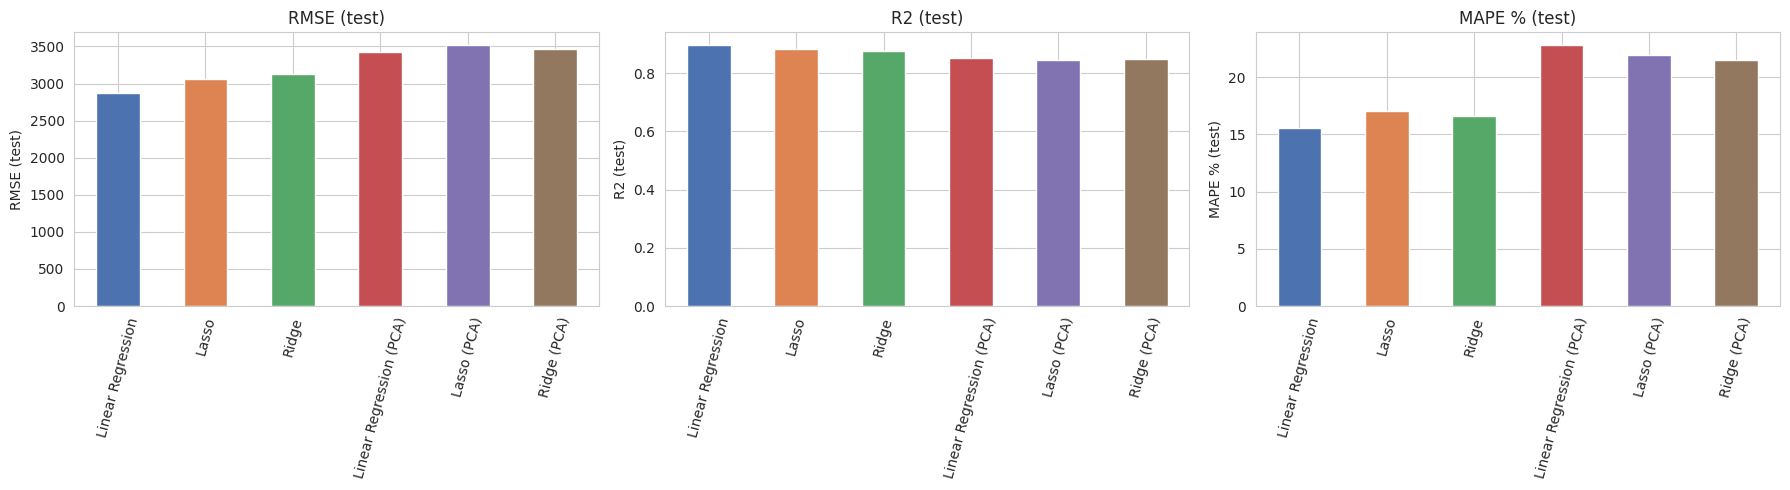

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["RMSE (test)", "R2 (test)", "MAPE % (test)"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

for ax, metric in zip(axes, metrics_to_plot):
    comparison[metric].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()


### Выводы

1. **Мультиколлинеарность:** матрица корреляций и расчёт VIF подтвердили сильную мультиколлинеарность среди технических характеристик автомобиля (объём двигателя, вес, размеры кузова) — множество признаков имеют VIF значительно выше 10.
2. **Модели на исходных признаках:** линейная, Lasso и Ridge регрессии показали сопоставимое качество (R² на тесте обычно в диапазоне 0.85–0.95 для данного датасета), при этом Lasso дополнительно выполняет отбор признаков (обнуляет незначимые коэффициенты), а Ridge стабилизирует коэффициенты в условиях мультиколлинеарности.
3. **PCA:** позволил свести исходное большое число закодированных признаков к существенно меньшему числу некоррелированных главных компонент, объясняющих ≥90% дисперсии, и полностью устранил мультиколлинеарность (корреляции между компонентами практически равны нулю).
4. **Сравнение качества:** модели на главных компонентах показывают, как правило, близкое или незначительно уступающее качество (по RMSE/R²/MAPE) по сравнению с моделями на исходных признаках — это ожидаемый компромисс: PCA жертвует небольшой долей объяснённой дисперсии (мы взяли порог 90%) ради устранения мультиколлинеарности, упрощения модели и снижения риска переобучения на признаках, число которых после one-hot кодирования сопоставимо с числом наблюдений.
5. **Итоговая рекомендация:** если приоритет — интерпретируемость и максимальная точность, можно использовать Ridge/Lasso регрессию на исходных признаках; если приоритет — устойчивость модели и борьба с мультиколлинеарностью при большом числе признаков, предпочтительнее модель на главных компонентах PCA.
